# Tarefa - Python para ciência de dados
Autor : Rhenan de Sousa Gonçalves

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/vendas_brasil_1.csv")
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## Entregável 1

### Item A

In [3]:
#checando as colunas nu'merias do dataframe 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [4]:
# catando os array numpy
p_unit = df['preco_unitario'].values
c_unit = df['custo_unitario'].values
qtdd = df['quantidade'].values
desc = df['desconto_pct'].values
rec_tot = df['receita_total'].values
frete = df['frete'].values
#sempre bom conferir
print(type(p_unit))

<class 'numpy.ndarray'>


## Item B

### Valor bruto de venda

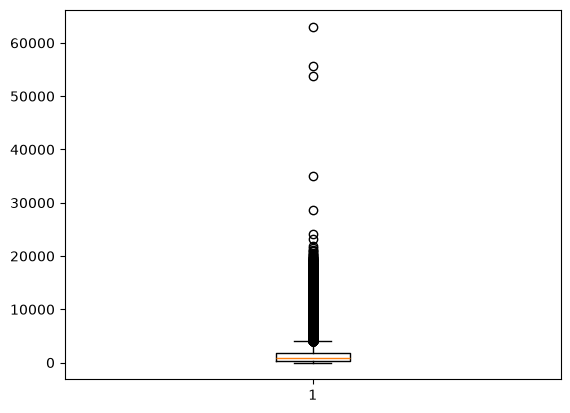

In [5]:
val_bruto = p_unit * qtdd
plt.boxplot(val_bruto)
plt.show()
## ta com pouco outlier na criança

In [6]:
m =np.mean(val_bruto)
sd = np.std(val_bruto)
len(np.where(val_bruto>m+3*sd)[0])/len(val_bruto)
#nah ssó 2%

0.02934843288938512

### Valor do desconto

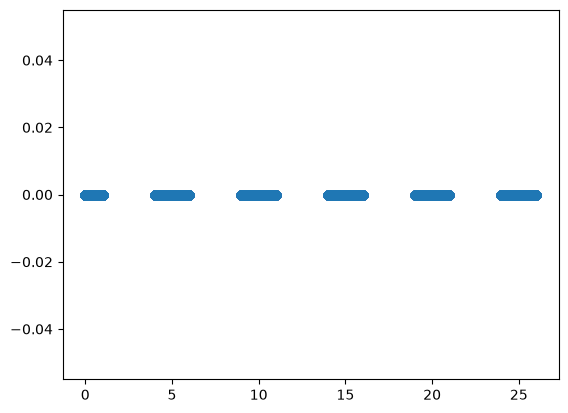

In [7]:
plt.scatter(x=desc, y=np.zeros_like(desc))

In [8]:
k = desc[np.logical_and(desc<1,desc>0)]
len(k)/len(desc)

0.17085360342398384

A coluna de desconto é bem suspeita: ela é percentual. Tem muitos valores entre 0 e 1, quase 20% dos dados. Desconto de 0.5% nao faz 
muito sentido, aparenta ser o valor percentual normalizado. enquanto o resto esta com o valor absoluto. Na duvida vou assumir que todos são absolutos, ms imagino que os pequenos sejam um erro de entrada de dados.

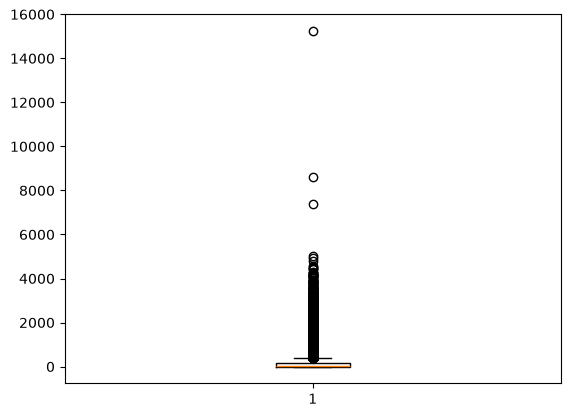

In [9]:
val_desconto = val_bruto * desc/100
plt.boxplot(val_desconto)
plt.show()

## msm skew da anterior

### Custo Total

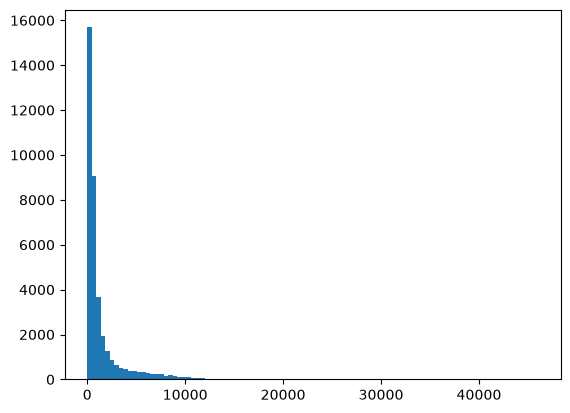

In [10]:
c_total = c_unit * qtdd
#variar o plot
plt.hist(c_total, bins = 100)
plt.show()

### Lucro Estimado

In [11]:
lucro = val_bruto - val_desconto  - c_total 
print(np.mean(lucro))
print(np.median(lucro))

342.0324771624532
122.91759999999988


## Item C

### receita acima da media

In [12]:
med = np.mean(rec_tot)
acima_da_media = rec_tot[rec_tot > med]
len(rec_tot)/len(acima_da_media)

#media altissima dnv, por conta dos outliers bizarros, mediada aqui seria mais robusto

4.072867042009528

### Vendas com prejuízo

In [13]:
preju = lucro[lucro<0]
print(len(preju))
print("porcentagem das vendas no negativo")
print(len(preju)/len(lucro))

2857
porcentagem das vendas no negativo
0.0759497035914613


### Desconto alto

In [14]:
## defini q desconto alto é acima de 25% pq sim
desc_alto = desc[desc>25]
len(desc_alto)/len(desc)

0.06124890342132547

## Item D

### REceita Média

In [15]:
np.mean(rec_tot)

np.float64(1891.6881729005502)

## maior receita

In [16]:
np.max(rec_tot)

np.float64(58430.28)

## menor receita


In [17]:
np.min(rec_tot)

np.float64(3.7)

## lucro medio

In [18]:
np.mean(lucro)

np.float64(342.0324771624532)

## qntdd de prejuizo

In [19]:
len(preju)

2857

## Conclusão

A empresa tá indo bem, tem poucas vendas no prejuizo e no geral ela ta lucrando bem (desconsiderando custos operacionais). As vendas tem um perfil especifico, onde alguns poucos itens tem valores muito altos e a maioria cai mais abaixo.

# Entregável 2

## Item A

In [20]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [22]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [23]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

In [24]:
df["data_venda"].head()
#df["data_venda_c"] = pd.to_datetime(df["data_venda"])

0    2022-04-13
1    2023-03-12
2    2022-09-28
3    2022-04-17
4    2022-03-13
Name: data_venda, dtype: str

1. O dataframe tem 37617 linhas e 21 colunas (df.info)
2. Sim, existem dados faltantes principalmente nas colunas fretem avaliacao_cliente e prazo_entrega_dias, além de poucos em outras colunas como verificado na funçao df.isna.sum()
3.  As colunas apontadas com tipo float64 e int64 na execução de df.info(), exceto mes, e data_venda
4. As outras. 

** Data_venda e mes são complicadas, estou colocando data_venda como  como numérica pois é mais "continua", consigo calcular as distâncias entre elas por ex, e isso aproxima mais de numerica. Já o mês puro provavelmente é usado mais como categoria mesmo, não tem muito essa questão de continuidade e distância entre os meses, e tem um numero bem limitado de valores possiveis, ai parece mais ser categorica.

## Item B
 

### Convertendo para datetime

In [25]:
df["data_venda"] = pd.to_datetime(df["data_venda"], format = "mixed")
print(df["data_venda"].min())
print(df["data_venda"].max())
# o periodo das datas ta muito bonitinho pra tar errado, esse format="mixed" é cabuloso msm, foi a mensagem de erro q sugeriu

2022-01-01 00:00:00
2023-12-31 00:00:00


###  padronizando categorica

In [26]:
df["vendedor"].unique()

<StringArray>
[    'Bruno Souza',     'Elisa Costa',     'João Vieira',    'Carla Mendes',
   'Henrique Dias',      'Inês Nunes',        'Ana Lima',     'Fábio Ramos',
      'Gabi Alves',  'Diego Ferreira',    ' João Vieira',   'Carla Mendes ',
               nan,    ' Fábio Ramos',       'Ana Lima ',    'Fábio Ramos ',
    'Bruno Souza ',    ' Elisa Costa',    'João Vieira ',     'Gabi Alves ',
     ' Inês Nunes',   ' Carla Mendes',  ' Henrique Dias', 'Diego Ferreira ',
       ' Ana Lima',    'Elisa Costa ',     'Inês Nunes ',     ' Gabi Alves',
 ' Diego Ferreira',    ' Bruno Souza',  'Henrique Dias ']
Length: 31, dtype: str

 só tirar os espaços do incicio , as letras maiusculas tao certinhas. Os nomes q faltam n vale a pena descartar a coluna, a informaçao da venda em si é mais importante, só o coitado do vendedor q vai ficar sem comissão mas aí faz parte. Só botar com desconhecido.

In [27]:
# só tirar os espaços do incicio , as letras maiusculas tao certinhas. Os nomes q faltam n vale a pena descartar a coluna, a informaçao da venda em si
# é mais importante, só o coitado do vendedor q vai ficar sem comissão mas aí faz parte. Só botar com desconhecido.
df.fillna({"vendedor": "Desconhecido"}, inplace=True)
df["vendedor"] = df["vendedor"].str.strip()
df["vendedor"].value_counts()

vendedor
João Vieira       3827
Ana Lima          3825
Elisa Costa       3822
Bruno Souza       3784
Gabi Alves        3780
Diego Ferreira    3753
Henrique Dias     3740
Carla Mendes      3696
Fábio Ramos       3683
Inês Nunes        3667
Desconhecido        40
Name: count, dtype: int64

Vou olhar mais uma categorica pra ver

In [28]:
df["fidelidade_cliente"].unique()

<StringArray>
['Diamante',   'Bronze',    'Prata',     'Ouro',     'ouro',    'prata',
   'bronze', 'DIAMANTE',    'PRATA',   'BRONZE',     'OURO', 'diamante']
Length: 12, dtype: str

In [29]:
#  COMO DESLIGA O CAPS LOCK
df["fidelidade_cliente"]=df["fidelidade_cliente"].str.upper()
df["fidelidade_cliente"].unique()

<StringArray>
['DIAMANTE', 'BRONZE', 'PRATA', 'OURO']
Length: 4, dtype: str

Vou mexer só nassas de categórica.

### Dados faltantes

fazer com uma coluna numerica pra ser legal, dado q ja mexi no nome do vendedor. Pegar a de avaliacao_cliente

<Axes: >

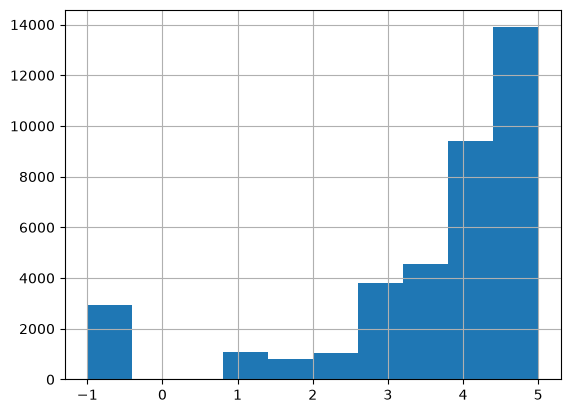

In [30]:
##fill temporario pra vizualizar no grafico 
temp = df["avaliacao_cliente"].fillna(-1)
temp.hist()

Tem bastante nan entao idealmente nao dá pra descartar. a maioria das avaliações ta entre 4 e 5, a media e ate a mediana vao ser bem puxadas pra cima. o problema é que a avaliação provavelmente depende fortemente do produto, alguns devem ser inerentemente mal avalaidos. vou checar 

In [31]:
df["produto"].value_counts()

produto
Jaqueta              1578
Garrafa Térmica      1569
Notebook             1542
Raquete              1534
Azeite               1528
                     ... 
Mel Orgânico            1
 Camiseta               1
Jaqueta                 1
Whey Protein            1
 Machine Learning       1
Name: count, Length: 67, dtype: int64

In [32]:
#vou ter q consolidar mais 1
df["produto"] = df["produto"].str.strip()
df["produto"].value_counts()

# oi sr vendedor hj vou levar pra casa uma unidade de machine learning


produto
Jaqueta                 1582
Garrafa Térmica         1573
Notebook                1547
Raquete                 1537
Azeite                  1536
Fone Bluetooth          1529
Granola                 1529
Bermuda                 1525
Tapete de Yoga          1521
Bicicleta               1520
Mel Orgânico            1517
Machine Learning        1514
Camiseta                1506
Calça Jeans             1505
Luva de Box             1495
Python para Dados       1493
Tablet                  1491
Smartphone              1477
Cálculo Vol.1           1472
Álgebra Linear          1471
Smartwatch              1471
Tênis                   1460
Whey Protein            1457
Estatística Aplicada    1456
Barra de Cereal         1433
Name: count, dtype: int64

In [33]:
df.groupby("produto")["avaliacao_cliente"].agg("median")

produto
Azeite                  4.010
Barra de Cereal         4.010
Bermuda                 4.010
Bicicleta               4.015
Calça Jeans             4.020
Camiseta                4.010
Cálculo Vol.1           4.010
Estatística Aplicada    4.010
Fone Bluetooth          4.020
Garrafa Térmica         4.015
Granola                 4.020
Jaqueta                 4.010
Luva de Box             4.010
Machine Learning        4.020
Mel Orgânico            4.020
Notebook                4.020
Python para Dados       4.020
Raquete                 4.020
Smartphone              4.020
Smartwatch              4.020
Tablet                  4.010
Tapete de Yoga          4.010
Tênis                   4.000
Whey Protein            4.020
Álgebra Linear          4.010
Name: avaliacao_cliente, dtype: float64

Ok os dados tão com muito cheiro de ser sintéticos. De qualquer forma vou seguir essa estrategia: imputar a cada dado faltante a mediana da avaliação para aquele tipo de produto (vou usar mediana pq imagino ter bastante outilers ent media seria paia)

In [34]:
df.fillna({"avaliacao_cliente": df.groupby("produto")["avaliacao_cliente"].transform("median")}, inplace=True)
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                 0
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente        0
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

## Item C

### Coluna de ano

In [35]:
df["ano_venda"] = df["data_venda"].dt.year.astype(int)
df["ano_venda"].value_counts()

ano_venda
2023    19015
2022    18602
Name: count, dtype: int64

In [36]:
df.columns

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco',
       'ano_venda'],
      dtype='str')

### Lucro total

<Axes: >

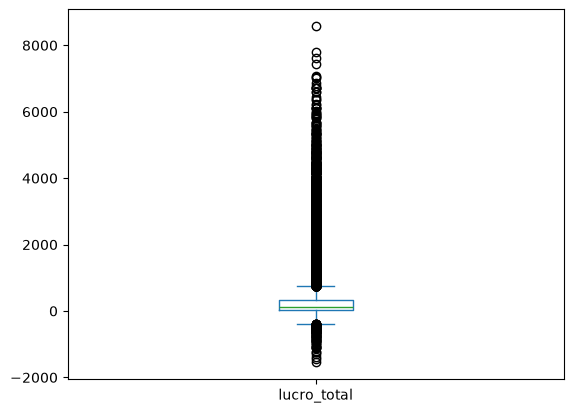

In [37]:
df["lucro_total"] = df.apply(  lambda row: ((row["preco_unitario"]*row["quantidade"])*(1-row["desconto_pct"]/100)
                                            - (row["custo_unitario"] * row["quantidade"]))
                             ,axis=1 )
df["lucro_total"].plot(kind="box")
#ta semelhante ao la da primeira questao, boa

### Faixa de lucro


In [38]:
labels = ["preju", "medio", "alto", "outlier"]
bins=[df["lucro_total"].min(), 0 ,1000, 2000,df["lucro_total"].max()]
df["faixa_lucro"] = pd.cut(df["lucro_total"], bins=bins,labels=labels)
df["faixa_lucro"].value_counts()

faixa_lucro
medio      31374
preju       2856
alto        2055
outlier     1331
Name: count, dtype: int64

## Item D

### quais vendas tiveram mais de 7000 de lucro

In [39]:
profit = df[df["lucro_total"]>7000]
profit
#q raquete cara do diacho é essa

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,lucro_total,faixa_lucro
836,2023-11-13,11,Manaus,Marketplace,Eletrônicos,Smartwatch,João Vieira,DIAMANTE,1724.59,1166.52,...,15.82,4.45,9.0,False,True,True,True,2023,7812.98000,outlier
4019,2023-02-08,2,Manaus,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,BRONZE,1541.15,1021.81,...,10.41,5.00,18.0,False,True,False,True,2023,7054.99900,outlier
26531,2023-12-02,12,Manaus,Loja Física,Eletrônicos,Tablet,Henrique Dias,BRONZE,1452.87,922.51,...,10.06,3.99,9.0,False,True,True,True,2023,7425.04000,outlier
29678,2022-09-29,9,Goiânia,Marketplace,Eletrônicos,Tablet,Carla Mendes,PRATA,1459.51,901.00,...,17.54,4.01,2.0,False,True,False,True,2022,7614.80860,outlier
30427,2022-01-31,1,São Paulo,Loja Física,Esportes,Raquete,Henrique Dias,PRATA,345.63,238.78,...,63.59,3.95,3.0,False,False,True,False,2022,8577.65335,outlier
30602,2022-04-27,4,Manaus,App Mobile,Eletrônicos,Tablet,Ana Lima,PRATA,1413.23,874.53,...,23.87,3.94,10.0,False,True,False,True,2022,7003.10000,outlier
35820,2022-09-04,9,Porto Alegre,App Mobile,Eletrônicos,Tablet,Elisa Costa,BRONZE,1681.10,1131.52,...,37.54,3.92,14.0,False,False,False,True,2022,7078.97710,outlier


In [40]:
df.iloc[30427]
#ata so é muita qtdd

data_venda            2022-01-31 00:00:00
mes                                     1
cidade                          São Paulo
canal_venda                   Loja Física
categoria                        Esportes
produto                           Raquete
vendedor                    Henrique Dias
fidelidade_cliente                  PRATA
preco_unitario                     345.63
custo_unitario                     238.78
margem_pct                          22.33
quantidade                            161
desconto_pct                         15.5
receita_total                    58430.28
frete                               63.59
avaliacao_cliente                    3.95
prazo_entrega_dias                    3.0
devolucao                           False
entrega_no_prazo                    False
alta_temporada                       True
flag_outlier_preco                  False
ano_venda                            2022
lucro_total                    8577.65335
faixa_lucro                       

Foram encontradas vendas de produtos caros e em grande quantidade, conforme o esperado para o maior lucro

### Vendas com devolulucao

In [41]:
devo = df [ df["devolucao"]] #a propria coluna booleana ja é mascara (:
no_devo = df [ np.logical_not( df["devolucao"])]
len(devo) / len(df)

0.09389371826567776

In [42]:
print(devo["avaliacao_cliente"].median() / no_devo["avaliacao_cliente"].median())
print(devo["avaliacao_cliente"].mean() / no_devo["avaliacao_cliente"].mean())

0.992537313432836
0.9010272073457889


In [43]:
devo["produto"].value_counts(normalize=True)

produto
Garrafa Térmica         0.046433
Granola                 0.044451
Cálculo Vol.1           0.043884
Fone Bluetooth          0.043035
Barra de Cereal         0.042752
Jaqueta                 0.042752
Azeite                  0.041903
Tapete de Yoga          0.041903
Bicicleta               0.041053
Mel Orgânico            0.040770
Tablet                  0.040770
Raquete                 0.040487
Whey Protein            0.040487
Python para Dados       0.040487
Machine Learning        0.039921
Estatística Aplicada    0.039071
Camiseta                0.038505
Notebook                0.038505
Smartwatch              0.038222
Calça Jeans             0.037939
Tênis                   0.037656
Luva de Box             0.037089
Smartphone              0.035108
Álgebra Linear          0.034258
Bermuda                 0.032559
Name: proportion, dtype: float64

In [44]:
no_devo["produto"].value_counts(normalize=True)

produto
Jaqueta                 0.041983
Notebook                0.041397
Bermuda                 0.041367
Garrafa Térmica         0.041338
Raquete                 0.040898
Azeite                  0.040722
Fone Bluetooth          0.040399
Bicicleta               0.040340
Machine Learning        0.040282
Mel Orgânico            0.040282
Tapete de Yoga          0.040282
Granola                 0.040252
Calça Jeans             0.040223
Camiseta                0.040194
Luva de Box             0.040018
Smartphone              0.039695
Python para Dados       0.039607
Álgebra Linear          0.039607
Tablet                  0.039519
Smartwatch              0.039196
Tênis                   0.038932
Estatística Aplicada    0.038668
Cálculo Vol.1           0.038639
Whey Protein            0.038551
Barra de Cereal         0.037612
Name: proportion, dtype: float64

Cerca de 10% dos produtos foram devolvidos. Curiosamente não há diferença significativa entre as avaliações dos produtos com devolução ou não, e todos os produtos tem mais ou menos a mesma de devolulçao. Poderia checar se tem associação entre devoluçao e loja e canal de venda mas como ta parecendo ser tudo sintético/aleatório é pointless.

### Venda por categoria

In [45]:
df["categoria"].value_counts()

categoria
Esportes       7646
Vestuário      7578
Eletrônicos    7515
Alimentação    7472
Livros         7406
Name: count, dtype: int64

In [46]:
#vou pegar comida e livros
df_bao = df[ df["categoria"].isin(["Livros","Alimentação"]) ]
df_bao

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,lucro_total,faixa_lucro
5,2023-12-02,12,Recife,Loja Física,Livros,Machine Learning,Carla Mendes,BRONZE,81.84,60.25,...,23.59,2.99,16.0,False,True,True,False,2023,193.57344,medio
6,2022-01-21,1,Manaus,Site Web,Livros,Python para Dados,Henrique Dias,BRONZE,124.28,83.82,...,38.10,1.99,3.0,False,True,True,False,2022,63.79680,medio
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,PRATA,35.72,21.62,...,24.98,3.03,18.0,True,False,False,False,2023,53.52360,medio
8,2022-05-02,5,São Paulo,Site Web,Alimentação,Whey Protein,Bruno Souza,PRATA,31.18,26.55,...,17.42,4.46,6.0,False,True,False,False,2022,-15.01524,preju
16,2023-10-26,10,Rio de Janeiro,Marketplace,Livros,Álgebra Linear,Elisa Costa,PRATA,56.93,48.29,...,17.63,3.55,16.0,False,True,False,False,2023,77.76000,medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37606,2023-12-31,1,Porto Alegre,App Mobile,Livros,Estatística Aplicada,Henrique Dias,PRATA,107.49,86.83,...,13.87,4.55,1.0,False,True,True,False,2023,-5.80235,preju
37611,2023-12-31,9,Salvador,Site Web,Livros,Cálculo Vol.1,João Vieira,PRATA,90.50,74.22,...,94.03,3.52,13.0,False,False,False,False,2023,-28.10500,preju
37612,2023-12-31,3,Porto Alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,BRONZE,73.11,47.38,...,8.15,4.95,NaN,False,False,False,False,2023,97.99803,medio
37613,2023-12-31,9,Salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,BRONZE,76.62,55.50,...,41.74,4.49,19.0,False,False,False,False,2023,155.05992,medio


In [47]:
print(len(df_bao))
print(len(df_bao) / len(df))

14878
0.39551266714517375


Vemos que tem 14878 vendas de produtos de categorias alimentação e livros, o que corresponde a 40% do dataset.

## Item E

## Categoria com maior receita total

In [48]:
df.groupby("categoria")["receita_total"].sum()

categoria
Alimentação     3331601.51
Eletrônicos    45017479.88
Esportes       11567480.75
Livros          4462597.93
Vestuário       6780473.93
Name: receita_total, dtype: float64

In [49]:
df.groupby("categoria")["receita_total"].count()

categoria
Alimentação    7472
Eletrônicos    7515
Esportes       7646
Livros         7406
Vestuário      7578
Name: receita_total, dtype: int64

In [50]:
df.groupby("categoria")["preco_unitario"].mean()

categoria
Alimentação     59.844425
Eletrônicos    802.363697
Esportes       201.010120
Livros          80.570585
Vestuário      120.696264
Name: preco_unitario, dtype: float64

Todas as categorias tiveram o exato mesmo numero de vendas, e a que teve mais receita foi extaamente a com maor preco unitario, eletronicos

### Canal de vendas mais popular

In [51]:
#faltou normalizar esse
def aux(s):
    if s == "SITEWEB":
        return "SITE WEB"
    return s
df["canal_venda"] = df["canal_venda"].str.strip().str.upper().str.replace("Í","I").apply(aux)
df.groupby("canal_venda")["canal_venda"].count()

canal_venda
APP MOBILE     11258
LOJA FISICA     7498
MARKETPLACE     5604
SITE WEB       11346
TELEVENDAS      1861
Name: canal_venda, dtype: int64

O canal com mais vendas é o site web, quase empatado com marketplace, enquando o menor é televendas

### Cidade com maior receita

In [52]:
df["cidade"].unique()

<StringArray>
[ 'Rio de Janeiro',          'Manaus',         'Goiânia',       'Fortaleza',
  'Belo Horizonte',          'Recife',       'São Paulo',    'Porto Alegre',
        'Salvador',        'Curitiba',        'salvador', 'Belo Horizonte ',
  'Rio de janeiro',         'Curtiba',       'Curitiba ',              'SP',
      ' Fortaleza',        'curitiba',              'RJ',        'S. Paulo',
       ' Salvador',         'Manaus ',       'São paulo',      'Fortaleza ',
       'Sao Paulo',              'BH', 'Rio de Janeiro ', ' Belo Horizonte',
         ' Recife',        'Slavador',  'Belo horizonte',             'Rio',
       ' Curitiba',         ' Manaus',        ' Goiânia',         'Recife ',
    'B. Horizonte',   'Porto Alegre ',  'Rio De Janeiro',      'São Paulo ',
        'Goiânia ',   ' Porto Alegre',       'Salvador ', ' Rio de Janeiro',
      ' São Paulo']
Length: 45, dtype: str

In [53]:
def aux2(s):
    ## checagem manual dos erros. em um caso maior tentaria gerar um embedding para cada palavra valida e ai aproximar 
    ## os erros dos embedidngs mais proximios; infelizmente n vai dar tempo de testar agr
    if s=="RJ" or s=="RIO":
        return "RIO DE JANEIRO"
    if s =="SP" or s=="S. PAULO" or s=="SAO PAULO":
        return "SÃO PAULO"
    if s=="SLAVADOR" :
        return "SALVADOR"
    if s=="B. HORIZONTE" or s=="BH":
        return "BELO HORIZONTE"
    if s=="CURTIBA":
        return "CURITIBA"
    return s

df["cidade"] = df["cidade"].str.strip().str.upper().apply(aux2)
df["cidade"].value_counts()

cidade
FORTALEZA         3853
CURITIBA          3842
MANAUS            3804
RECIFE            3796
GOIÂNIA           3785
PORTO ALEGRE      3722
RIO DE JANEIRO    3720
SALVADOR          3717
SÃO PAULO         3693
BELO HORIZONTE    3685
Name: count, dtype: int64

In [54]:
df.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)

cidade
RECIFE            7662241.79
MANAUS            7459161.23
FORTALEZA         7242081.82
GOIÂNIA           7178113.69
PORTO ALEGRE      7048428.17
CURITIBA          6993175.07
SALVADOR          6918656.01
BELO HORIZONTE    6914747.61
RIO DE JANEIRO    6880176.34
SÃO PAULO         6862852.27
Name: receita_total, dtype: float64

Todas tiveram mais ou menos a mesma receita, apesar de recife estar um pouco a frente

### Categoria com maior luxro

In [55]:
df.groupby("categoria")["lucro_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    8.141113e+06
Esportes       2.082461e+06
Vestuário      1.232406e+06
Livros         8.126898e+05
Alimentação    5.975651e+05
Name: lucro_total, dtype: float64

Aqui eletronicos claramente foi a maior.

## Item F

In [56]:
regis = { "RECIFE":"NE","MANAUS":"N","FORTALEZA":"NE","GOIÂNIA":"CO","PORTO ALEGRE":"S","CURITIBA":"S", "SALVADOR":"NE","BELO HORIZONTE":"SE",
       "RIO DE JANEIRO":"SE","SÃO PAULO":"SE" }

regis = pd.DataFrame(regis.items(), columns = ["cidade","regiao"])
regis

,cidade,regiao
0,RECIFE,NE
1,MANAUS,N
2,FORTALEZA,NE
3,GOIÂNIA,CO
4,PORTO ALEGRE,S
5,CURITIBA,S
6,SALVADOR,NE
7,BELO HORIZONTE,SE
8,RIO DE JANEIRO,SE
9,SÃO PAULO,SE


In [57]:
df = pd.merge(df,regis, left_on="cidade",right_on="cidade",how="left" )
df

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,lucro_total,faixa_lucro,regiao
0,2022-04-13,4,RIO DE JANEIRO,APP MOBILE,Eletrônicos,Notebook,Bruno Souza,DIAMANTE,739.39,561.75,...,4.92,5.0,False,True,False,False,2022,1391.91720,alto,SE
1,2023-03-12,3,MANAUS,SITE WEB,Vestuário,Camiseta,Elisa Costa,BRONZE,187.48,135.15,...,4.98,19.0,True,False,False,False,2023,256.02560,medio,N
2,2022-09-28,9,GOIÂNIA,APP MOBILE,Vestuário,Tênis,João Vieira,BRONZE,76.11,61.40,...,3.47,NaN,True,True,False,False,2022,198.48122,medio,CO
3,2022-04-17,4,FORTALEZA,SITE WEB,Vestuário,Calça Jeans,Carla Mendes,BRONZE,145.86,88.53,...,4.50,16.0,False,True,False,False,2022,621.00324,medio,NE
4,2022-03-13,3,BELO HORIZONTE,APP MOBILE,Esportes,Bicicleta,João Vieira,BRONZE,133.92,107.25,...,3.49,13.0,False,True,False,False,2022,0.55560,medio,SE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-12-31,3,PORTO ALEGRE,APP MOBILE,Alimentação,Barra de Cereal,Gabi Alves,BRONZE,73.11,47.38,...,4.95,NaN,False,False,False,False,2023,97.99803,medio,S
37613,2023-12-31,9,SALVADOR,SITE WEB,Alimentação,Mel Orgânico,Henrique Dias,BRONZE,76.62,55.50,...,4.49,19.0,False,False,False,False,2023,155.05992,medio,NE
37614,2023-12-31,2,SALVADOR,LOJA FISICA,Alimentação,Whey Protein,Fábio Ramos,BRONZE,55.15,36.94,...,4.02,14.0,False,True,False,False,2023,127.47000,medio,NE
37615,2023-12-31,11,SÃO PAULO,SITE WEB,Esportes,Tapete de Yoga,João Vieira,BRONZE,197.09,167.23,...,3.50,6.0,False,True,True,False,2023,58.64033,medio,SE


<Axes: xlabel='categoria', ylabel='lucro_total'>

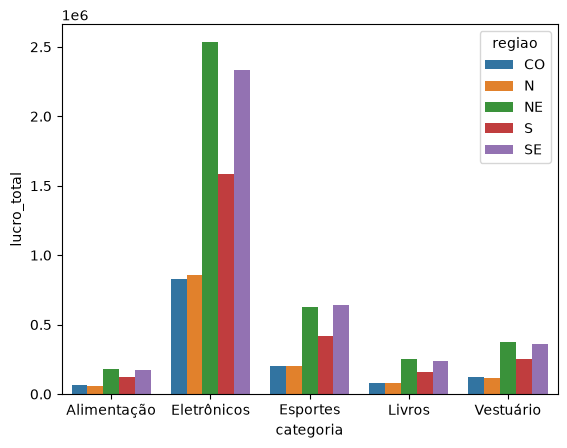

In [58]:
plot = df.groupby(["regiao","categoria"])["lucro_total"].sum().reset_index()
sns.barplot(data = plot, x="categoria", y="lucro_total", hue="regiao")

Da para ver que a proporção de vendas em cada região é mais ou menos igual para todas as categorias, com o sudeste e nordeste liderando.

### Conclusão

Quase confimado que o dataset é artificial, em muitos locais diferentes vejo proporções se mantendo exatamente igual entre categorias, contagens iguais, etc. Mas deu para ver que se trata de vendas de produtos muito diversos em lojas físicas, televendas e site em todo o Brasil, parece uma Lojas Americanas, que ganha o lucro principal nas regiões mais populosas (Sul e Sudeste) vendendo eletrônico.

# Entregável 3

## Item A

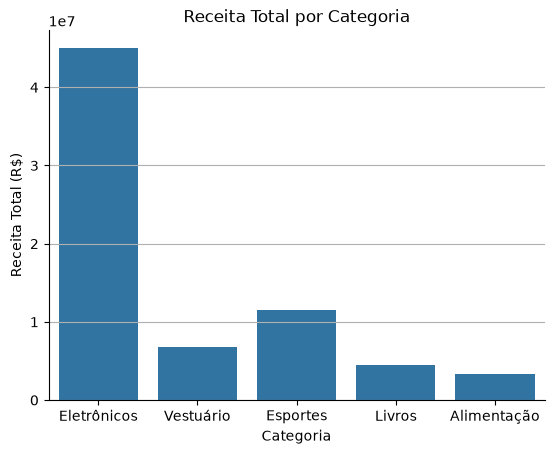

In [59]:
sns.barplot(data=df, x="categoria", y="receita_total", estimator="sum", errorbar=None)
sns.despine()
plt.title("Receita Total por Categoria")
plt.ylabel("Receita Total (R$)")
plt.xlabel("Categoria")
plt.grid(axis="y")
plt.show()

O gráfico mostra claramente que a receita total de eletrònicos é muito superior a das outras categorias, com esportes vindo como um segundo colocado e o resto abaixo.

## Item B

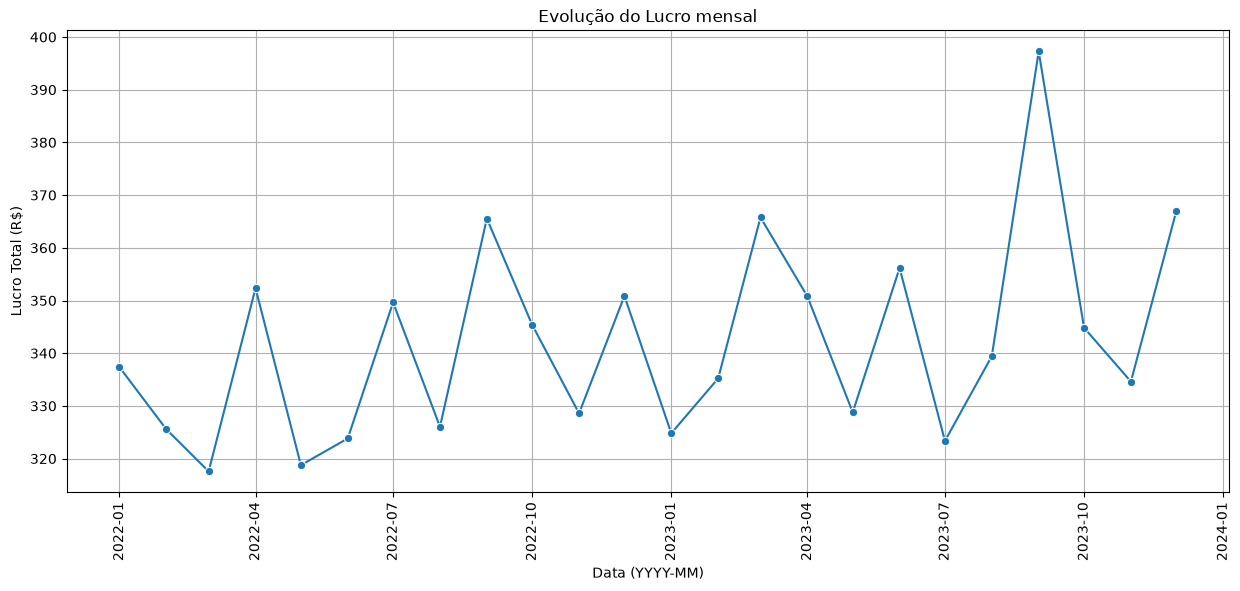

In [61]:
#plotar a venda mensal ao longo do tempo
df["mes_ano"] = df["ano_venda"].astype(str) + '-' + df["mes"].astype(str)
df["mes_ano"] = pd.to_datetime(df["mes_ano"], format="%Y-%m")

plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x=df["mes_ano"],y="lucro_total",errorbar=None, marker="o")
plt.xticks(rotation=90)
plt.title("Evolução do Lucro mensal")
plt.ylabel("Lucro Total (R$)")
plt.xlabel("Data (YYYY-MM)")
plt.grid()
plt.show()

O gráfico mostra uma forte sazonalidade mensal nas vendas, e uma tendência geral de aumento.

## Item C

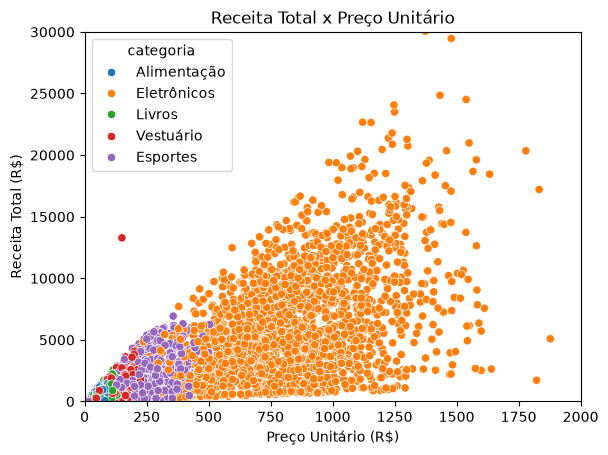

In [77]:
df_sample = df.sample(frac=0.3)
sns.scatterplot(data= df_sample, x='preco_unitario', y='receita_total', hue="categoria")
plt.title('Receita Total x Preço Unitário')
plt.xlabel('Preço Unitário (R$)')
plt.ylabel('Receita Total (R$)')
plt.xlim(0, 2000) #tem alguns outliers q vao ser escondidos, mas ai ada pra ver melhor
plt.ylim(0, 30000) #tem alguns outliers q vao ser escondidos, mas ai ada pra ver melhor
plt.show()

O gráfico mostra que há uma relação entre os preços unitários e as receitas totais, além de verificar que eletrônicos dominam os maiores preços e as maiores receitas.

## Item D

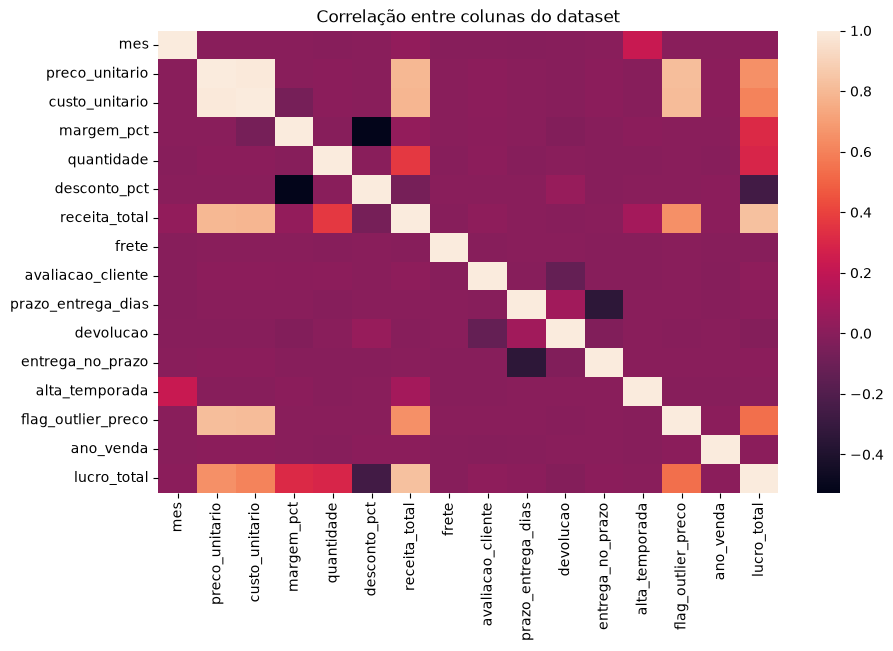

In [86]:
plt.figure(figsize=(10, 6))
sns.heatmap( df.corr(numeric_only=True))
plt.title("Correlação entre colunas do dataset")
plt.show()

Vê-se que o lucro total está fortemente relacionado a diversas colunas, e o prazo de entrega aparenta afetar se ela chega no prazo ou não. Nada muito surpreendente.